# GEDI Footprint Extraction Workflow

Extracts GEDI Level 2A shots over an area of interest, filters to high-quality returns, and exports point and footprint (25 m buffer) GeoJSON files.

**Bounding box:** Set from a `.gdb` boundary file (interactive dialog) **or** entered manually below.

---
## Setup

Install required packages if you haven't already:

```bash
# in Google Colab:
#   !pip install earthaccess h5py numpy pandas geopandas shapely fiona -q
# in VS Code terminal:
#   python -m pip install earthaccess h5py numpy pandas geopandas shapely fiona
```

In [3]:
#------------ imports ----------------------------------------------------------
import earthaccess
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import datetime
import os
import tkinter as tk
from tkinter import filedialog, simpledialog
import fiona
from pyproj import CRS, Transformer



c:\Users\davisk10\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 1: Set Output Folder and File Header

A dialog will open asking you to:
1. Select the folder where output files (CSV, GeoJSON) will be saved
2. Enter a short header used to name all output files (e.g. `bpines` → `bpines_gedi_shots.csv`)

In [4]:
data_folder = input("Enter output folder path: ").strip().strip('"')
file_header = input("Enter file name header (e.g. 'bpines'): ").strip().lower().replace(" ", "_")

csv_path            = os.path.join(data_folder, f'{file_header}_gedi_shots.csv')
geojson_path        = os.path.join(data_folder, f'{file_header}_gedi_shots.geojson')
buffer_geojson_path = os.path.join(data_folder, f'{file_header}_gedi_footprints.geojson')

print(f"\nOutput files will be:")
print(f"  {csv_path}")
print(f"  {geojson_path}")
print(f"  {buffer_geojson_path}")


Output files will be:
  C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots.csv
  C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots.geojson
  C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_footprints.geojson


---
## Step 2: Define Area of Interest Bounding Box

**Option A** — Load from a `.gdb` boundary file (recommended): run the cell below.

**Option B** — Enter coordinates manually: skip to the manual cell further below.

### Option A: Load boundary from .gdb

In [5]:
# Select the boundary GDB
gdb_path = input("Paste the path to your .gdb folder: ").strip().strip('"')

if not gdb_path:
    raise SystemExit("No .gdb folder path entered. Exiting.")

# List available layers
layers = fiona.listlayers(gdb_path)
print("\nLayers found in geodatabase:")
for i, layer in enumerate(layers):
    print(f"  {i + 1}: {layer}")

# Ask user to pick a layer
layer_index = int(input(f"\nEnter the number of the layer to use (1–{len(layers)}): ").strip())

if not layer_index:
    raise SystemExit("No layer selected. Exiting.")

layer_name = layers[layer_index - 1]
print(f"\nUsing layer: {layer_name}")

# Load the boundary layer and compute bounding box
boundary = gpd.read_file(gdb_path, layer=layer_name)
boundary_wgs84 = boundary.to_crs("EPSG:4326")

minx, miny, maxx, maxy = boundary_wgs84.total_bounds
LON_MIN, LAT_MIN, LON_MAX, LAT_MAX = minx, miny, maxx, maxy

print(f"\nBounding box derived from .gdb boundary:")
print(f"LAT_MIN, LAT_MAX = {LAT_MIN:.6f}, {LAT_MAX:.6f}")
print(f"LON_MIN, LON_MAX = {LON_MIN:.6f}, {LON_MAX:.6f}")


Layers found in geodatabase:
  1: Polygons_2
  2: treesandgardens_XYTableToPoint
  3: gedi_arb_points
  4: gedi_arb_points_Buffer
  5: blob_Buffer
  6: blob_Buffer2
  7: ZonalSt_gedi_ar1
  8: drone_percentile
  9: percentiles_drone_lidar
  10: percentiles_dron
  11: Line
  12: arb_blob
  13: redwood_trees
  14: GEDIFootprints25mDiameter_ExportTable
  15: GEDIFootprints25mDiameter_ExportFeatures
  16: gedi_arb_points_ExportFeatures
  17: gedi_arb_points_ExportF_Clip
  18: GEDI_Footprint_4_trees
  19: GEDI_Footprint_4_trees__ATTACH
  20: GEDI_Footprints_tallest_gt_trees1_trees_Merge
  21: GEDI_Footprints_tallest_gt_trees1_trees_Merge__ATTACH
  22: GEDI_Footprints_tallest_gt_trees1_trees_Merge1
  23: GEDI_Footprints_tallest_gt_trees1_trees_Merge1__ATTACH
  24: GEDI_Footprint_5_trees
  25: GEDI_Footprint_5_trees__ATTACH
  26: GEDI_Footprint_Merge
  27: GEDI_Footprint_Merge__ATTACH

Using layer: arb_blob

Bounding box derived from .gdb boundary:
LAT_MIN, LAT_MAX = 35.309664, 35.311200
LON_

### Option B: Insert coordinates manually

Only run this cell if you skipped Option A.

In [4]:
# -------- Insert coordinates for area of interest -----------------------------
LAT_MIN, LAT_MAX = 35.309, 35.312
LON_MIN, LON_MAX = -120.664, -120.657

# Create a boundary polygon from the manual coordinates (needed for clipping in Step 9)
from shapely.geometry import box
boundary = gpd.GeoDataFrame(geometry=[box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)], crs="EPSG:4326")

---
## Step 3: Login to NASA Earthdata

In [6]:
# ---------- Login to NASA Earthdata -------------------------------------------
# prompts for NASA Earthdata username and password
earthaccess.login()

---
## Step 4: Search for GEDI Granules

In [7]:
# ---------- Search for GEDI granules over area of interest --------------------
print('Searching for GEDI granules...')
results = earthaccess.search_data(
    short_name='GEDI02_A',
    version='002',
    bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)
)
print(f'Found {len(results)} granules covering your arboretum')

Searching for GEDI granules...
Found 17 granules covering your arboretum


c:\Users\davisk10\miniconda3\Lib\site-packages\earthaccess\results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


---
## Step 5: Stream Granules and Extract Shots

Streams each granule directly — no download needed. (~20 min depending on granule count)

In [8]:
# --- Stream each granule and extract shots (~20 min) --------------------------
all_shots = []
waveform_store = {}   # stores raw waveform arrays keyed by shot_number
                      # kept separate from the DataFrame because each shot has
                      # a variable number of waveform samples (~200–2000 values)

for granule in results:
    filename = granule['meta']['native-id']
    print(f'\nProcessing: {filename}')

    try:
        # Stream the file directly — no download needed
        files = earthaccess.open([granule])
        h5file = h5py.File(files[0], 'r')
        beams = [k for k in h5file.keys() if k.startswith('BEAM')]

        for beam in beams:
            try:
                lat = h5file[beam]['lat_lowestmode'][:]
                lon = h5file[beam]['lon_lowestmode'][:]

                # Filter to arboretum bounding box
                mask = (
                    (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                    (lon >= LON_MIN) & (lon <= LON_MAX)
                )

                if mask.sum() == 0:
                    continue

                print(f'  {beam}: {mask.sum()} shots in arboretum')

                rh = h5file[beam]['rh'][mask]

                # Date from filename
                try:
                    year = int(filename[9:13])
                    doy  = int(filename[13:16])
                    date = datetime.datetime(year, 1, 1) + datetime.timedelta(doy - 1)
                    date_str = date.strftime('%Y-%m-%d')
                except:
                    date_str = 'unknown'

                shot_data = {
                    'filename':     filename,
                    'beam':         beam,
                    'date':         date_str,
                    'lat':          lat[mask],
                    'lon':          lon[mask],
                    'rh25':         rh[:, 25],
                    'rh50':         rh[:, 50],
                    'rh75':         rh[:, 75],
                    'rh85':         rh[:, 85],
                    'rh95':         rh[:, 95],  
                    'rh98':         rh[:, 98], #relative height at 98th percentile (top of forest canopy height in m)
                    'rh99':         rh[:, 99],
                    'rh100':        rh[:, 100],
                    'sensitivity':  h5file[beam]['sensitivity'][mask], #how well detected ground return through the canopy, ranges from 0 to 1
                                                                        #0.9 - 1.0 → excellent — laser punched through canopy cleanly and found ground
                    'quality_flag': h5file[beam]['quality_flag'][mask],
                    'degrade_flag': h5file[beam]['degrade_flag'][mask],
                    'shot_number':  h5file[beam]['shot_number'][mask].astype(str),
                }

                all_shots.append(pd.DataFrame(shot_data))
                # ── Extract raw waveforms for shots in bounding box ───────────
                # rxwaveform is one long 1D array for the entire beam —
                # rx_sample_start_index and rx_sample_count tell us where
                # each individual shot's waveform starts and how long it is
                rx_waveform   = h5file[beam]['rxwaveform'][:]
                start_indices = h5file[beam]['rx_sample_start_index'][mask]
                sample_counts = h5file[beam]['rx_sample_count'][mask]
                shot_numbers  = h5file[beam]['shot_number'][mask]   # ← add this line

                for i in range(mask.sum()):
                    sn    = str(shot_numbers[i])
                    start = start_indices[i]
                    count = sample_counts[i]
                    # slice out just this shot's waveform from the full beam array
                    waveform_store[sn] = rx_waveform[start : start + count]


            except KeyError as e:
                print(f'  Skipping {beam} — missing field: {e}')
                continue

        h5file.close()

    except Exception as e:
        print(f'  Error: {e}')
        continue

c:\Users\davisk10\miniconda3\Lib\site-packages\earthaccess\store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)



Processing: GEDI02_A_2020112133647_O07692_02_T04072_02_003_01_V002


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 323.24it/s]
PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.40s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 6864.65it/s]


  BEAM0011: 4 shots in arboretum
  Skipping BEAM0011 — missing field: "Unable to synchronously open object (object 'rxwaveform' doesn't exist)"

Processing: GEDI02_A_2020200095731_O09054_03_T02271_02_003_01_V002


...

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 364.12it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.05s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 2400.86it/s]


  BEAM0011: 5 shots in arboretum
  Skipping BEAM0011 — missing field: "Unable to synchronously open object (object 'rxwaveform' doesn't exist)"

Processing: GEDI02_A_2025094173239_O35746_02_T06918_02_004_02_V002


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 202.41it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 1708.47it/s]


  BEAM0110: 4 shots in arboretum
  Skipping BEAM0110 — missing field: "Unable to synchronously open object (object 'rxwaveform' doesn't exist)"

Processing: GEDI02_A_2025179080244_O37058_02_T02802_02_004_02_V002


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 394.42it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.17s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 490.33it/s]


---
## Step 6: Filter to High-Quality Shots and Save Outputs

In [9]:
# ------------- Combine all shots ----------------------------------------------
if len(all_shots) == 0:
    print('\nNo shots found in arboretum area')
else:
    combined = pd.concat(all_shots, ignore_index=True)
    print(f'\nTotal shots found: {len(combined)}')

    # Filter to high quality shots only
    quality = combined[
        (combined['quality_flag'] == 1) &
        (combined['degrade_flag'] == 0)
    ].copy()
    print(f'High quality shots: {len(quality)}')
    print(quality[['date', 'beam', 'lat', 'lon', 'rh98', 'sensitivity']].to_string())

    # Ensure shot_number stays as string (ArcGIS Pro compatibility)
    quality['shot_number'] = quality['shot_number'].astype(str)

    # Save CSV
    quality.to_csv(csv_path, index=False)
    print(f'\nCSV saved: {csv_path}')


Total shots found: 32
High quality shots: 18
          date      beam        lat         lon   rh98  sensitivity
0   2020-04-21  BEAM0011  35.309895 -120.663444   8.23     0.914987
1   2020-04-21  BEAM0011  35.310242 -120.662984  14.93     0.943995
2   2020-04-21  BEAM0011  35.310589 -120.662524   6.13     0.955509
3   2020-04-21  BEAM0011  35.310935 -120.662066   9.88     0.946373
12  2021-08-16  BEAM0011  35.310809 -120.662771  11.56     0.905081
16  2022-03-15  BEAM1000  35.309887 -120.662030   2.58     0.961871
17  2022-03-15  BEAM1000  35.310237 -120.661568   9.85     0.966369
18  2022-03-15  BEAM1000  35.310586 -120.661106   4.45     0.966245
19  2022-03-15  BEAM1000  35.310935 -120.660644   5.16     0.963093
23  2024-06-23  BEAM0011  35.309738 -120.663056   4.78     0.925517
24  2024-06-23  BEAM0011  35.310086 -120.662598   7.77     0.943286
25  2024-06-23  BEAM0011  35.310438 -120.662134  11.88     0.928673
26  2024-06-23  BEAM0011  35.310793 -120.661667   5.56     0.942738
27

---
## Step 7: Export Center Coordinate Points of Footprints to GeoJSON

In [10]:
# ── Step 7: Build point GeoDataFrame ──────────────────────────────────────────
if len(quality) == 0:
    print('No quality shots to export. Exiting.')
else:
    geometry_pts = [Point(lon, lat) for lon, lat in zip(quality['lon'], quality['lat'])]
    gdf_points = gpd.GeoDataFrame(quality, geometry=geometry_pts, crs='EPSG:4326')

    # Save point GeoJSON
    gdf_points.to_file(geojson_path, driver='GeoJSON')
    print(f'Point GeoJSON saved: {geojson_path}')

Point GeoJSON saved: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots.geojson


---
## Step 8: Create 25 m Footprint Buffers and Export

**WHY WE REPROJECT:**  
GEDI points are stored in WGS84 (EPSG:4326), where coordinates are in degrees. Buffering in degrees does NOT give you metres — 0.0001° of longitude is ~9 m near the equator but changes with latitude.

Solution: reproject to a CRS measured in metres, buffer by exactly 12.5 m (radius), then reproject back to WGS84.

UTM Zone 10N (EPSG:32610) covers central California and is appropriate for this study area. Adjust the EPSG code if your ROI is in a different UTM zone.

**WHAT THE BUFFER DOES:**  
Each GEDI shot records a single lat/lon centre point, but the real laser footprint illuminates a ~25 m diameter circle on the ground. `buffer(12.5)` expands each point into a circle with radius 12.5 m, giving a 25 m diameter polygon that matches the physical footprint. When you later extract biomass, canopy height, or image pixel values WITHIN these polygons, you are sampling the same area the lidar saw.

In [11]:
# ── Step 8: Create 25 m footprint buffers ─────────────────────────────────────
UTM_CRS = 'EPSG:32610'   # UTM Zone 10N — change if your site is elsewhere

gdf_utm = gdf_points.to_crs(UTM_CRS)
gdf_utm['geometry'] = gdf_utm.geometry.buffer(12.5)    # 12.5 m radius → 25 m diameter
gdf_footprints = gdf_utm.to_crs('EPSG:4326')           # reproject back to WGS84

gdf_footprints.to_file(buffer_geojson_path, driver='GeoJSON')
print(f'Footprint GeoJSON saved (25 m buffers): {buffer_geojson_path}')

print('\nDone! Load the GeoJSON files into QGIS or ArcGIS Pro.')
print('Outputs:')
print(f'  Points     → {geojson_path}')
print(f'  Footprints → {buffer_geojson_path}')
print(f'  CSV        → {csv_path}')

Footprint GeoJSON saved (25 m buffers): C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_footprints.geojson

Done! Load the GeoJSON files into QGIS or ArcGIS Pro.
Outputs:
  Points     → C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots.geojson
  Footprints → C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_footprints.geojson
  CSV        → C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots.csv


---
## Diagnostic: Why Were Shots Rejected?

Re-streams all granules without quality filtering and prints a breakdown of rejection reasons. Run this if you want to understand why shots were excluded.

In [ ]:
# ------ Diagnostic: why were shots rejected? ----------------------------------

all_shots_unfiltered = []

for granule in results:
    filename = granule['meta']['native-id']

    try:
        files = earthaccess.open([granule])
        h5file = h5py.File(files[0], 'r')
        beams = [k for k in h5file.keys() if k.startswith('BEAM')]

        for beam in beams:
            try:
                lat = h5file[beam]['lat_lowestmode'][:]
                lon = h5file[beam]['lon_lowestmode'][:]

                mask = (
                    (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                    (lon >= LON_MIN) & (lon <= LON_MAX)
                )

                if mask.sum() == 0:
                    continue

                quality_flag = h5file[beam]['quality_flag'][mask]
                degrade_flag = h5file[beam]['degrade_flag'][mask]
                sensitivity  = h5file[beam]['sensitivity'][mask]

                # Date from filename
                try:
                    year = int(filename[9:13])
                    doy  = int(filename[13:16])
                    date = datetime.datetime(year, 1, 1) + datetime.timedelta(doy - 1)
                    date_str = date.strftime('%Y-%m-%d')
                except:
                    date_str = 'unknown'

                for i in range(mask.sum()):
                    all_shots_unfiltered.append({
                        'filename':     filename,
                        'beam':         beam,
                        'date':         date_str,
                        'lat':          lat[mask][i],
                        'lon':          lon[mask][i],
                        'quality_flag': quality_flag[i],
                        'degrade_flag': degrade_flag[i],
                        'sensitivity':  sensitivity[i],
                        'rejected':     quality_flag[i] != 1 or degrade_flag[i] != 0
                    })

            except KeyError as e:
                continue

        h5file.close()

    except Exception as e:
        print(f'Error: {e}')
        continue

# ── Summary ───────────────────────────────────────────────────────────────────
df_all = pd.DataFrame(all_shots_unfiltered)

print(f'Total shots in bounding box: {len(df_all)}')
print(f'Accepted (quality=1, degrade=0): {len(df_all[~df_all["rejected"]])}')
print(f'Rejected: {len(df_all[df_all["rejected"]])}')
print()
print('Rejection breakdown:')
print(f'  quality_flag = 0: {len(df_all[df_all["quality_flag"] == 0])}')
print(f'  degrade_flag != 0: {len(df_all[df_all["degrade_flag"] != 0])}')
print()
print('Rejected shots by date and beam:')
rejected = df_all[df_all['rejected']]
print(rejected[['date', 'beam', 'lat', 'lon', 'quality_flag', 'degrade_flag', 'sensitivity']].to_string())

c:\Users\davisk10\miniconda3\Lib\site-packages\earthaccess\store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00,  7.91it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 3095.43it/s]
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 229.05it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:04<00:00,  4.29s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 8867.45it/s]
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 202.94it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.15s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 1933.75it/s]
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 180.01it/s]
PROCESSING TASKS | : 1

---
## Step 9: Clip GEDI Footprints to Previously Entered Study Area Bounday 

In [13]:
## Step 9: Clip Footprints to Study Area Boundary

# Reproject boundary to WGS84 to match footprints
boundary_wgs84 = boundary.to_crs("EPSG:4326")
boundary_union = boundary_wgs84.union_all()  # single geometry for comparison

# Keep only footprints completely within the boundary
gdf_footprints_clipped = gdf_footprints[gdf_footprints.geometry.within(boundary_union)].copy()

# Match points to surviving footprints using shot_number
gdf_points_clipped = gdf_points[gdf_points['shot_number'].isin(gdf_footprints_clipped['shot_number'])].copy()

print(f"Footprints before filtering:      {len(gdf_footprints)}")
print(f"Footprints fully within boundary: {len(gdf_footprints_clipped)}")
print(f"Points matched to footprints:     {len(gdf_points_clipped)}")

# Save outputs
clipped_footprints_path = os.path.join(data_folder, f'{file_header}_gedi_footprints_clipped.geojson')
clipped_points_path     = os.path.join(data_folder, f'{file_header}_gedi_shots_clipped.geojson')

gdf_footprints_clipped.to_file(clipped_footprints_path, driver='GeoJSON')
gdf_points_clipped.to_file(clipped_points_path, driver='GeoJSON')

print(f"\nClipped footprints saved: {clipped_footprints_path}")
print(f"Clipped points saved:     {clipped_points_path}")

Footprints before filtering:      18
Footprints fully within boundary: 6
Points matched to footprints:     6

Clipped footprints saved: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_footprints_clipped.geojson
Clipped points saved:     C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots_clipped.geojson


## Messing Around with Graph Ouputs for GEDI Data

In [ ]:
# ── RH Canopy Profile — One Chart Per Footprint ───────────────────────────────
# Horizontal bar chart showing each rh metric as a canopy height for that footprint.
# One figure saved per footprint. UAV CHM overlay to be added later.

import matplotlib.pyplot as plt
import math

rh_cols        = ['rh25', 'rh50', 'rh75', 'rh95', 'rh98', 'rh99', 'rh100']
rh_percentiles = [25,      50,     75,     95,     98,     99,     100]

for plot_idx, (_, row) in enumerate(gdf_points_clipped.iterrows()):

    fig, ax = plt.subplots(figsize=(6, 7))

    rh_values = [row[col] for col in rh_cols]

    # Height intervals between consecutive rh percentiles
    heights   = [0] + rh_values
    intervals = [heights[i+1] - heights[i] for i in range(len(rh_values))]
    percentile_widths = [rh_percentiles[0]] + [
        rh_percentiles[i] - rh_percentiles[i-1] for i in range(1, len(rh_percentiles))
    ]

    ax.barh(
        y      = [heights[i] + intervals[i] / 2 for i in range(len(intervals))],
        width  = percentile_widths,
        height = intervals,
        color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.75,
        label='GEDI RH profile'
    )

    # Label each rh metric
    for rh_val, rh_pct in zip(rh_values, rh_percentiles):
        ax.axhline(rh_val, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
        ax.text(max(percentile_widths) * 0.98, rh_val + 0.2,
                f'rh{rh_pct} = {rh_val:.1f} m',
                fontsize=7, ha='right', va='bottom')

    ax.set_xlabel('Percentile interval width (%)', fontsize=9)
    ax.set_ylabel('Height (m)', fontsize=9)
    ax.set_ylim(0, max(rh_values) * 1.15)
    ax.set_title(
        f'Footprint {plot_idx + 1} — Canopy Height Profile\n'
        f'Date: {row["date"]}  |  Beam: {row["beam"]}\n'
        f'rh98: {row["rh98"]:.1f} m  |  Sensitivity: {row["sensitivity"]:.2f}',
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    #optional for saving the graphs created
    #save_path = os.path.join(data_folder, f'{file_header}_footprint{plot_idx + 1}_rh_profile.png')
    #plt.savefig(save_path, dpi=150, bbox_inches='tight')
    #print(f"Saved: {save_path}")

    plt.show()

    # ── Raw GEDI Waveform Plot — One Chart Per Footprint ─────────────────────────
# Plots the raw received waveform (rxwaveform) for each clipped footprint.
# The waveform shows laser return intensity vs sample index (proxy for height) —
# peaks indicate surfaces where the laser reflected (ground, understory, canopy).
# This is the black line from the reference figure.

for plot_idx, (_, row) in enumerate(gdf_points_clipped.iterrows()):

    sn = row['shot_number']

    if sn not in waveform_store:
        print(f"Footprint {plot_idx + 1}: no waveform found for shot {sn}")
        continue

    waveform = waveform_store[sn]

    # Sample index runs top-down (first sample = top of atmosphere,
    # last sample = ground), so we flip it so ground is at the bottom
    samples = np.arange(len(waveform))
    samples_flipped = samples[::-1]

    fig, ax = plt.subplots(figsize=(5, 7))

    ax.plot(
        waveform, samples_flipped,
        color='black', linewidth=1.2, label='GEDI waveform'
    )

    # Shade the area under the waveform like the reference figure
    ax.fill_betweenx(
        samples_flipped, 0, waveform,
        color='steelblue', alpha=0.2
    )

    ax.set_xlabel('Return intensity (counts)', fontsize=9)
    ax.set_ylabel('Sample index (↑ = higher in canopy)', fontsize=9)
    ax.set_title(
        f'Footprint {plot_idx + 1} — Raw GEDI Waveform\n'
        f'Date: {row["date"]}  |  Beam: {row["beam"]}\n'
        f'rh98: {row["rh98"]:.1f} m  |  Sensitivity: {row["sensitivity"]:.2f}',
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

## Step 10: Monte Carlo Simulation of New Footprint Center Coordinate Locations
==========================================================================================

Based on:
  - 'Simulation-Based Correction of Geolocation Errors in GEDI Footprint Positions
     Using Monte Carlo Approach'
  - 'The impact of geolocation uncertainty on GEDI tropical forest canopy height
     estimation and change monitoring'

Method:
  Each GEDI footprint location is shifted with randomly generated position errors
  modelled using the GEDI geolocation uncertainty (Dubayah et al., 2020a):

      x*_i = x + s_i * cos(theta_i)
      y*_i = y + s_i * sin(theta_i)

  where:
    (x*_i, y*_i) = shifted GEDI footprint center coordinate
    (x, y)       = GEDI product reported footprint center coordinate
    s_i          ~ N(mu=0 m, sigma=10 m)  [geolocation uncertainty]
    theta_i      ~ Uniform(0, 2*pi)       [random direction]
    n            = 300 simulations per footprint

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# STEP A — Assign reading-order numbers (top-to-bottom, left-to-right)
# ════════════════════════════════════════════════════════════════════════════
# Groups points into "rows" based on latitude proximity, then numbers each
# row left-to-right (low lon → high lon), rows ordered top-to-bottom (high lat → low lat)

ROW_TOLERANCE_M = 15.0   # points within this many metres of latitude count as the same "row"
                          # tune this based on your point spacing — too small splits a row
                          # into multiple rows, too large merges separate rows together

row_tol_deg = ROW_TOLERANCE_M / 111320.0   # ~111,320 m per degree latitude

# Ensure shot_number is a consistent string type before any merging
gdf_points_clipped['shot_number'] = gdf_points_clipped['shot_number'].astype(str)

gdf_sorted = gdf_points_clipped.sort_values('lat', ascending=False).reset_index(drop=True)

row_ids = []
current_row = 0
row_ref_lat = gdf_sorted.loc[0, 'lat']

for lat_val in gdf_sorted['lat']:
    if row_ref_lat - lat_val > row_tol_deg:
        current_row += 1
        row_ref_lat = lat_val
    row_ids.append(current_row)

gdf_sorted['row_id'] = row_ids
gdf_sorted = gdf_sorted.sort_values(['row_id', 'lon'], ascending=[True, True]).reset_index(drop=True)
gdf_sorted['reading_order_id'] = gdf_sorted.index + 1   # start at 1, not 0

gdf_points_clipped = gdf_points_clipped.merge(
    gdf_sorted[['shot_number', 'reading_order_id']],
    on='shot_number',
    how='left'
)

n_missing_a = gdf_points_clipped['reading_order_id'].isna().sum()
if n_missing_a > 0:
    print(f"WARNING: {n_missing_a} points in gdf_points_clipped have no reading_order_id — check shot_number dtypes")

print(gdf_points_clipped[['shot_number', 'lat', 'lon', 'reading_order_id']]
      .sort_values('reading_order_id').to_string(index=False))
# ════════════════════════════════════════════════════════════════════════════
# STEP A.1 — Propagate reading_order_id onto footprints, re-save GeoJSON files
# ════════════════════════════════════════════════════════════════════════════
# gdf_footprints_clipped doesn't have reading_order_id yet — it was only
# assigned to gdf_points_clipped in Step A. Merge it across using shot_number,
# then overwrite both clipped GeoJSON files so the attribute table includes
# the new column when opened in QGIS/ArcGIS.

gdf_footprints_clipped['shot_number'] = gdf_footprints_clipped['shot_number'].astype(str)

if 'reading_order_id' in gdf_footprints_clipped.columns:
    gdf_footprints_clipped = gdf_footprints_clipped.drop(columns='reading_order_id')

reading_id_lookup = gdf_points_clipped[['shot_number', 'reading_order_id']].drop_duplicates()

gdf_footprints_clipped = gdf_footprints_clipped.merge(
    reading_id_lookup, on='shot_number', how='left'
)

n_missing_fp = gdf_footprints_clipped['reading_order_id'].isna().sum()
if n_missing_fp > 0:
    print(f"WARNING: {n_missing_fp} footprints did not get a reading_order_id")
else:
    print("reading_order_id successfully added to gdf_footprints_clipped")

# Re-save both clipped GeoJSON files, now including reading_order_id
gdf_footprints_clipped.to_file(clipped_footprints_path, driver='GeoJSON')
gdf_points_clipped.to_file(clipped_points_path, driver='GeoJSON')

print(f"Footprints GeoJSON updated: {clipped_footprints_path}")
print(f"Points GeoJSON updated:     {clipped_points_path}")

       shot_number       lat         lon  reading_order_id
151690300300267578 35.310809 -120.662771                 1
 76920300200076713 35.310589 -120.662524                 2
313210300200185367 35.310438 -120.662134                 3
357460600200326393 35.310392 -120.661510                 4
 76920300200076712 35.310242 -120.662984                 5
184280800200188204 35.310237 -120.661568                 6
reading_order_id successfully added to gdf_footprints_clipped
Footprints GeoJSON updated: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_footprints_clipped.geojson
Points GeoJSON updated:     C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_gedi_shots_clipped.geojson


Input footprints : 6
Monte Carlo n    : 300
Geolocation σ    : 10.0 m  (μ = 0.0 m)

Monte Carlo output shape : (1800, 11)
  (6 footprints × 300 simulations = 1,800 rows)

Per-footprint summary (first 5 rows):


,footprint_id,lon_original,lat_original,lon_shifted_mean,lat_shifted_mean,lon_shifted_std,lat_shifted_std,mean_radial_disp_m,n_simulations,geometry
0,151690300300267578,-120.662771,35.310809,-120.662767,35.310805,0.000079,0.000071,8.568966,300,POINT (-120.66277 35.31081)
1,184280800200188204,-120.661568,35.310237,-120.661571,35.310230,0.000077,0.000063,7.879112,300,POINT (-120.66157 35.31023)
2,313210300200185367,-120.662134,35.310438,-120.662130,35.310442,0.000077,0.000064,8.082123,300,POINT (-120.66213 35.31044)
3,357460600200326393,-120.661510,35.310392,-120.661518,35.310388,0.000077,0.000059,7.754447,300,POINT (-120.66152 35.31039)
4,76920300200076712,-120.662984,35.310242,-120.662979,35.310244,0.000070,0.000061,7.331981,300,POINT (-120.66298 35.31024)


reading_order_id successfully appended to gdf_mc and gdf_summary
Excel file saved to: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_monte_carlo_results.xlsx


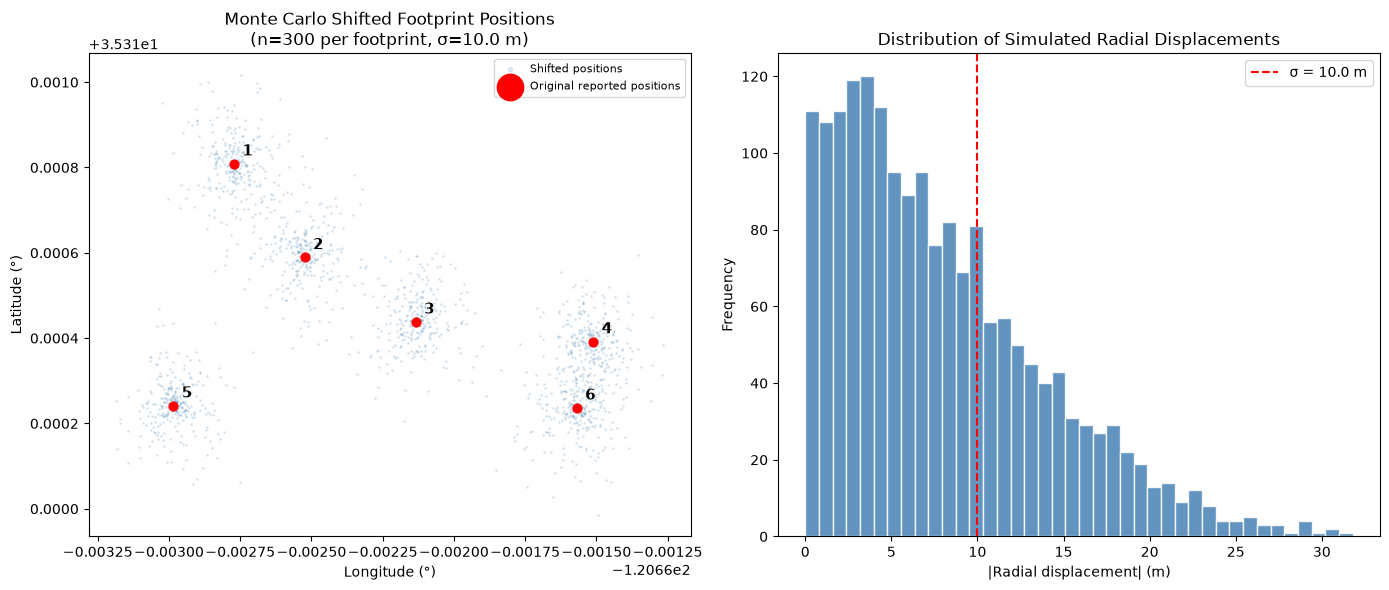

Figure saved.

Outputs ready:
  gdf_mc      – full Monte Carlo simulation GeoDataFrame (all footprints × all iterations)
  gdf_summary – per-footprint ensemble summary with mean-corrected positions


In [15]:
# ── Simulation parameters ────────────────────────────────────────────────────
N_SIMULATIONS = 300       # number of random shifted positions generated per footprint
SIGMA_M       = 10.0      # GEDI geolocation uncertainty: 1 standard deviation = 10 m
                          # (Dubayah et al. 2020a) — most shots land within 10 m of true position
MU_M          = 0.0       # zero-mean error: no systematic bias assumed, errors are random
SEED          = 42        # fixing the seed makes results reproducible run-to-run
                          # remove or change this for true randomness in production
rng           = np.random.default_rng(SEED)

# ── Coordinate reference systems ──────────────────────────────────────────────
# GEDI reports positions in WGS84 (degrees), but we need to apply metre-scale
# offsets. We temporarily project to UTM (metres) to do the geometry, then
# project back to WGS84 for the output.
WGS84      = 'EPSG:4326'
METRIC_CRS = 'EPSG:32610'    # UTM Zone 10N — covers central California
                              # change this if your study area is in a different UTM zone

to_metric = Transformer.from_crs(WGS84, METRIC_CRS, always_xy=True)
to_wgs84  = Transformer.from_crs(METRIC_CRS, WGS84,  always_xy=True)

print(f"Input footprints : {len(gdf_points_clipped):,}")
print(f"Monte Carlo n    : {N_SIMULATIONS}")
print(f"Geolocation σ    : {SIGMA_M} m  (μ = {MU_M} m)")

# ── Core Monte Carlo loop ─────────────────────────────────────────────────────
# For each real GEDI footprint, we simulate N_SIMULATIONS possible "true"
# positions by applying random position errors. This models the uncertainty
# in where the laser actually hit the ground vs where GEDI says it did.
records = []

for fp_idx, row in gdf_points_clipped.iterrows():

    footprint_id = row['shot_number']


    # Step 1: get the reported WGS84 position and convert to metres (UTM)
    lon_orig = row.geometry.x
    lat_orig = row.geometry.y
    x_m, y_m = to_metric.transform(lon_orig, lat_orig)

    # Step 2: sample random radial displacements
    # s_i ~ N(0, 10m) — how far each simulated point is shifted from the original
    # This follows a normal distribution: most shifts are small, few are large
    s_i = rng.normal(loc=MU_M, scale=SIGMA_M, size=N_SIMULATIONS)

    # Step 3: sample random azimuth directions
    # theta_i ~ Uniform(0, 2π) — the direction of each shift is completely random
    # This means errors are equally likely in any compass direction
    theta_i = rng.uniform(low=0.0, high=2 * np.pi, size=N_SIMULATIONS)

    # Step 4: apply the offsets in metric space
    # x*_i = x + s_i * cos(theta_i)   (east-west shift)
    # y*_i = y + s_i * sin(theta_i)   (north-south shift)
    x_star = x_m + s_i * np.cos(theta_i)
    y_star = y_m + s_i * np.sin(theta_i)

    # Step 5: project the shifted positions back to WGS84 (degrees)
    lon_star, lat_star = to_wgs84.transform(x_star, y_star)

    # Step 6: store each simulation as a row in the results list
    for sim_idx in range(N_SIMULATIONS):
        rec = {
            'footprint_id'   : footprint_id,              # which original footprint this belongs to
            'simulation_id'  : sim_idx + 1,           # which simulation iteration (1–300)
            'lon_original'   : lon_orig,              # original reported GEDI position
            'lat_original'   : lat_orig,
            's_i_m'          : s_i[sim_idx],          # radial displacement magnitude in metres
            'theta_i_deg'    : np.degrees(theta_i[sim_idx]),  # shift direction in degrees
            'dx_m'           : s_i[sim_idx] * np.cos(theta_i[sim_idx]),  # east-west component
            'dy_m'           : s_i[sim_idx] * np.sin(theta_i[sim_idx]),  # north-south component
            'lon_shifted'    : lon_star[sim_idx],     # shifted position (the simulated true location)
            'lat_shifted'    : lat_star[sim_idx],
            'geometry'       : Point(lon_star[sim_idx], lat_star[sim_idx]),
        }
        records.append(rec)

# ── Assemble into a single GeoD98
# 
# ataFrame ──────────────────────────────────────
# Result: one row per simulation per footprint
# e.g. 6 footprints × 300 simulations = 1,800 rows
gdf_mc = gpd.GeoDataFrame(records, geometry='geometry', crs=WGS84)

print(f"\nMonte Carlo output shape : {gdf_mc.shape}")
print(f"  ({len(gdf_points_clipped)} footprints × {N_SIMULATIONS} simulations = "
      f"{len(gdf_points_clipped) * N_SIMULATIONS:,} rows)")

# ── Per-footprint summary statistics ─────────────────────────────────────────
# Collapse the 300 simulations per footprint into summary stats:
#   mean shifted position → best estimate of the "true" corrected location
#   std of shifted positions → how uncertain the corrected position is
#   mean radial displacement → average error magnitude across all simulations
summary = (
    gdf_mc
    .groupby('footprint_id')
    .agg(
        lon_original       = ('lon_original',  'first'),
        lat_original       = ('lat_original',  'first'),
        lon_shifted_mean   = ('lon_shifted',   'mean'),   # ensemble mean corrected longitude
        lat_shifted_mean   = ('lat_shifted',   'mean'),   # ensemble mean corrected latitude
        lon_shifted_std    = ('lon_shifted',   'std'),    # spread in longitude across simulations
        lat_shifted_std    = ('lat_shifted',   'std'),    # spread in latitude across simulations
        mean_radial_disp_m = ('s_i_m',         lambda x: np.abs(x).mean()),  # avg displacement
        n_simulations      = ('simulation_id', 'count'),
    )
    .reset_index()
)

# Attach the ensemble-mean corrected position as the geometry
summary_geom = [
    Point(row.lon_shifted_mean, row.lat_shifted_mean)
    for _, row in summary.iterrows()
]
gdf_summary = gpd.GeoDataFrame(summary, geometry=summary_geom, crs=WGS84)

print("\nPer-footprint summary (first 5 rows):")
display(gdf_summary.head())

# STEP E — Append reading_order_id to gdf_mc and gdf_summary
# ════════════════════════════════════════════════════════════════════════════
if 'reading_order_id' not in gdf_points_clipped.columns:
    raise RuntimeError(
        "reading_order_id missing from gdf_points_clipped — Step A must run "
        "successfully before this step. Re-run from the top of the notebook."
    )

reading_order_lookup = gdf_points_clipped[['shot_number', 'reading_order_id']].drop_duplicates()
reading_order_lookup['shot_number'] = reading_order_lookup['shot_number'].astype(str)

gdf_mc['footprint_id'] = gdf_mc['footprint_id'].astype(str)
gdf_summary['footprint_id'] = gdf_summary['footprint_id'].astype(str)

gdf_mc = gdf_mc.merge(
    reading_order_lookup, left_on='footprint_id', right_on='shot_number', how='left'
).drop(columns='shot_number')

gdf_summary = gdf_summary.merge(
    reading_order_lookup, left_on='footprint_id', right_on='shot_number', how='left'
).drop(columns='shot_number')

n_missing_e = gdf_mc['reading_order_id'].isna().sum()
if n_missing_e > 0:
    print(f"WARNING: {n_missing_e} rows in gdf_mc have no matching reading_order_id")
else:
    print("reading_order_id successfully appended to gdf_mc and gdf_summary")


# ════════════════════════════════════════════════════════════════════════════
# STEP F — Export results to Excel for inspection/editing
# ════════════════════════════════════════════════════════════════════════════
excel_path = os.path.join(data_folder, f'{file_header}_monte_carlo_results.xlsx')

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    gdf_mc.drop(columns='geometry').to_excel(writer, sheet_name='all_simulations', index=False)
    gdf_summary.drop(columns='geometry').to_excel(writer, sheet_name='per_footprint_summary', index=False)

print(f"Excel file saved to: {excel_path}")


# ── Diagnostic plots ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: shows the cloud of 300 shifted positions around each original footprint
# Each cluster of blue dots represents the uncertainty envelope for one GEDI shot
ax = axes[0]
ax.scatter(
    gdf_mc['lon_shifted'], gdf_mc['lat_shifted'],
    s=1, alpha=0.15, color='steelblue', label='Shifted positions'
)
ax.scatter(
    gdf_points_clipped.geometry.x, gdf_points_clipped.geometry.y,
    s=40, color='red', zorder=5, label='Original reported positions'
)
# Label each original point with its reading-order number
for _, row in gdf_points_clipped.iterrows():
    ax.annotate(
        str(int(row['reading_order_id'])),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='black',
        zorder=6,
    )
    
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Monte Carlo Shifted Footprint Positions\n'
             f'(n={N_SIMULATIONS} per footprint, σ={SIGMA_M} m)')
ax.legend(markerscale=3, fontsize=8)

# Right panel: histogram of how large the random shifts were
# Should look like a half-normal distribution centred near 0
# The red line marks the 10 m 1-sigma threshold
ax2 = axes[1]
ax2.hist(np.abs(gdf_mc['s_i_m']), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(SIGMA_M, color='red', linestyle='--', linewidth=1.5, label=f'σ = {SIGMA_M} m')
ax2.set_xlabel('|Radial displacement| (m)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Simulated Radial Displacements')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(data_folder, f'{file_header}_monte_carlo.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

print("\nOutputs ready:")
print("  gdf_mc      – full Monte Carlo simulation GeoDataFrame (all footprints × all iterations)")
print("  gdf_summary – per-footprint ensemble summary with mean-corrected positions")

## ── Plot shifted footprint circles for each original footprint ────────────────
Replicates the style of panel (b) in the paper:
 - red circle = original reported GEDI 25m footprint
 - black circles = 300 simulated shifted 25m footprints

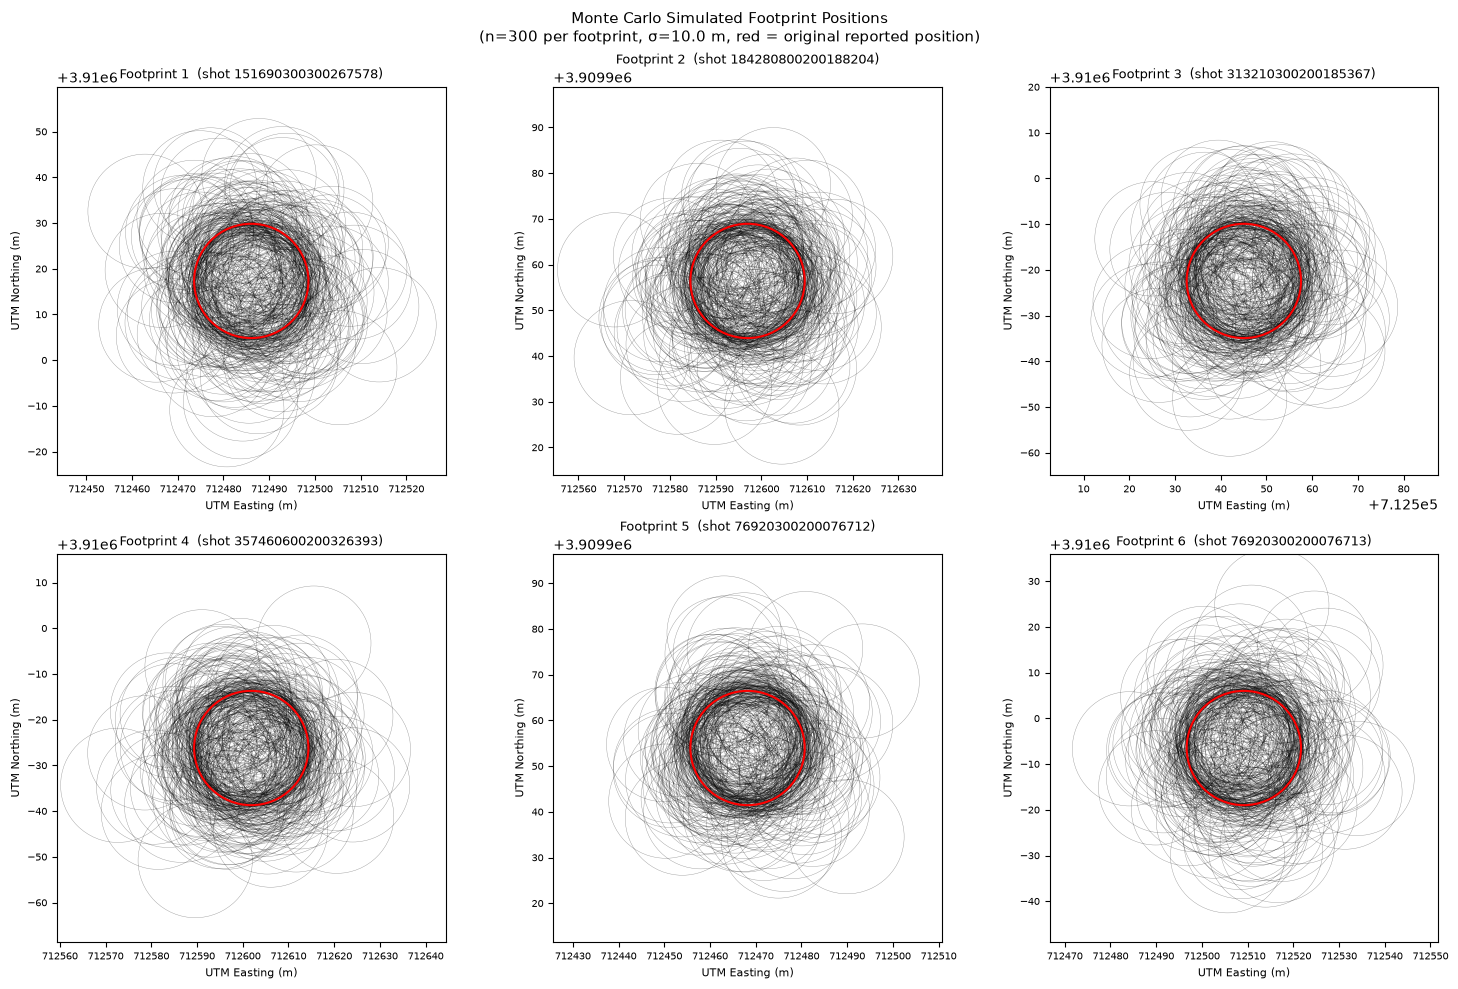

Figure saved.


In [16]:
# ── Plot shifted footprint circles for each original footprint ────────────────
# Replicates the style of panel (b) in the paper:
#   - red circle = original reported GEDI 25m footprint
#   - black circles = 300 simulated shifted 25m footprints

from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

n_footprints = len(gdf_points_clipped)
n_cols = 3
n_rows = math.ceil(n_footprints / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

FOOTPRINT_RADIUS_M = 12.5   # 25m diameter footprint → 12.5m radius


for plot_idx, (fp_idx, fp_sims) in enumerate(gdf_mc.groupby('footprint_id')):

    ax = axes[plot_idx]

    # Get original position in metres (UTM)
    lon_orig = fp_sims['lon_original'].iloc[0]
    lat_orig = fp_sims['lat_original'].iloc[0]
    x_orig, y_orig = to_metric.transform(lon_orig, lat_orig)

    # Draw each of the 300 shifted 25m circles in black
    for _, sim_row in fp_sims.iterrows():
        x_shift, y_shift = to_metric.transform(sim_row['lon_shifted'], sim_row['lat_shifted'])
        circle = plt.Circle(
            (x_shift, y_shift), FOOTPRINT_RADIUS_M,
            color='black', fill=False, linewidth=0.3, alpha=0.4
        )
        ax.add_patch(circle)

    # Draw the original reported footprint in red on top
    original_circle = plt.Circle(
        (x_orig, y_orig), FOOTPRINT_RADIUS_M,
        color='red', fill=False, linewidth=1.5
    )
    ax.add_patch(original_circle)

    # Set axis limits with padding around the footprint cloud
    pad = FOOTPRINT_RADIUS_M + SIGMA_M * 3   # show out to ~3σ
    ax.set_xlim(x_orig - pad, x_orig + pad)
    ax.set_ylim(y_orig - pad, y_orig + pad)
    ax.set_aspect('equal')

    ax.set_xlabel('UTM Easting (m)', fontsize=8)
    ax.set_ylabel('UTM Northing (m)', fontsize=8)
    ax.set_title(f'Footprint {plot_idx + 1}  (shot {fp_idx})', fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle(
    f'Monte Carlo Simulated Footprint Positions\n'
    f'(n={N_SIMULATIONS} per footprint, σ={SIGMA_M} m, red = original reported position)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(
    os.path.join(data_folder, f'{file_header}_monte_carlo_circles.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Figure saved.")

## Combine R and Python? (no) 

In [ ]:
# This code can be moved later to start before the R notebook code runs, just placing it here now for reference
# this will need to be the first python cell of the notebook, before any R code is run, otherwise it will throw an error
import os

os.environ["R_HOME"] = r"C:\Program Files\R\R-4.5.2"
os.environ["PATH"] = (
    r"C:\Program Files\R\R-4.5.2\bin\x64;"
    r"C:\Program Files\R\R-4.5.2\bin;"
    + os.environ["PATH"]
)
%load_ext rpy2.ipython

In [ ]:
%%R

library(lidR)
library(terra)
library(sf)
library(RCSF)

## Generate the simulated RH metrics from the Canopy height model for each of the 300 footprints for each of the 6 footprints. potentially just start with comparisons of RH95
just have python read the GeoTIFF file created by the R notebook for now

In [ ]:
# load GeoTIFF file created by running the R code in the las_to_chm_workflow notebook
# extract RH 95 data from each generated new coordinate for each footprint


In [17]:
# ════════════════════════════════════════════════════════════════════════════
# STEP H — Extract RH95 from UAV CHM at each simulated footprint center
# ════════════════════════════════════════════════════════════════════════════
# For each simulated coordinate (one of the 300 Monte Carlo positions per
# footprint), extract a 12.5 m radius circular buffer (matching GEDI's 25 m
# footprint diameter) from the UAV-derived Canopy Height Model (CHM) GeoTIFF,
# and compute the 95th percentile of CHM pixel values within that buffer as
# the UAV-equivalent RH95 metric for that simulated position.
#
# Methodology reference:
#   Liu, A. et al. (2021), "The impact of geolocation uncertainty on GEDI
#   tropical forest canopy height estimation and change monitoring",
#   Earth and Space Science / Science of Remote Sensing — uses the same
#   300-simulation, 0/10 m Monte Carlo geolocation model and extracts
#   relative-height percentiles (h95, h85, h75) from reference canopy data
#   at each simulated position to quantify geolocation-driven RH variability.

import rasterio
from rasterio.windows import from_bounds
from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping
import numpy as np

# ── Prompt user for the CHM GeoTIFF path ──────────────────────────────────────
chm_path = input("Enter the full path to the UAV CHM GeoTIFF file: ").strip()

if not os.path.exists(chm_path):
    raise FileNotFoundError(f"CHM file not found at: {chm_path}")

BUFFER_RADIUS_M = 12.5   # 25 m GEDI footprint diameter → 12.5 m radius buffer

print(f"\nUsing CHM file: {chm_path}")
print(f"Buffer radius  : {BUFFER_RADIUS_M} m")

with rasterio.open(chm_path) as chm_src:
    chm_crs = chm_src.crs
    chm_nodata = chm_src.nodata

    print(f"CHM CRS        : {chm_crs}")
    print(f"CHM nodata     : {chm_nodata}")
    print(f"CHM resolution : {chm_src.res}")

    # Reproject simulated points from WGS84 into the CHM's native CRS so the
    # 12.5 m buffer radius is applied correctly in real metres, not degrees
    to_chm_crs = Transformer.from_crs(WGS84, chm_crs, always_xy=True)

    rh95_uav = np.full(len(gdf_mc), np.nan)

    n_total = len(gdf_mc)
    n_outside = 0
    n_nodata = 0

    # main loop for getting raster info within each simulated footprint buffer
    for i, (lon, lat) in enumerate(zip(gdf_mc['lon_shifted'], gdf_mc['lat_shifted'])):

        x_chm, y_chm = to_chm_crs.transform(lon, lat) # converts each points coordinates into the CHM's CRS 
        buffer_geom = Point(x_chm, y_chm).buffer(BUFFER_RADIUS_M) # draws a 12.5m buffer around each point

        try:
            out_image, out_transform = rio_mask( # clips the raster down to just the pixels within the circle (12.5m radius)
                chm_src, [mapping(buffer_geom)], crop=True, filled=True, nodata=chm_nodata
            )
        except ValueError:
            # Buffer falls entirely outside the raster extent
            n_outside += 1
            continue

        # filtering and computing the RH95 percentile
        chm_values = out_image[0]

        if chm_nodata is not None:
            valid_values = chm_values[chm_values != chm_nodata]
        else:
            valid_values = chm_values.flatten()

        # Also drop NaNs in case the raster uses NaN as nodata
        valid_values = valid_values[~np.isnan(valid_values)]

        if valid_values.size == 0:
            n_nodata += 1
            continue

        rh95_uav[i] = np.percentile(valid_values, 95) #actual RH95 calculation (value below which 95% of the CHm heights in the buffer fall)

        if (i + 1) % 500 == 0:
            print(f"  Processed {i + 1:,} / {n_total:,} simulated points...")

gdf_mc['rh95_uav_chm'] = rh95_uav

print(f"\nRH95 extraction complete.")
print(f"  Total simulated points        : {n_total:,}")
print(f"  Points outside CHM extent     : {n_outside:,}")
print(f"  Points with no valid CHM data : {n_nodata:,}")
print(f"  Points successfully extracted : {n_total - n_outside - n_nodata:,}")


# ── Roll the per-simulation RH95 values up into the per-footprint summary ────
rh95_summary = (
    gdf_mc
    .groupby('footprint_id')['rh95_uav_chm']
    .agg(
        rh95_uav_mean='mean',   # ensemble mean UAV RH95 across all simulations
        rh95_uav_std='std',     # spread in UAV RH95 due to geolocation uncertainty
        rh95_uav_p25=lambda x: np.nanpercentile(x, 25),  # matches paper's IQR approach
        rh95_uav_p75=lambda x: np.nanpercentile(x, 75),
    )
)
rh95_summary['rh95_uav_iqr'] = rh95_summary['rh95_uav_p75'] - rh95_summary['rh95_uav_p25']
rh95_summary = rh95_summary.reset_index()

gdf_summary = gdf_summary.merge(rh95_summary, on='footprint_id', how='left')

print("\nPer-footprint RH95 summary (first 5 rows):")
display(gdf_summary[['footprint_id', 'reading_order_id', 'rh95_uav_mean',
                      'rh95_uav_std', 'rh95_uav_iqr']].head())


# ════════════════════════════════════════════════════════════════════════════
# STEP I — Re-save updated results to the Excel file and GeoJSON
# ════════════════════════════════════════════════════════════════════════════
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    gdf_mc.drop(columns='geometry').to_excel(writer, sheet_name='all_simulations', index=False)
    gdf_summary.drop(columns='geometry').to_excel(writer, sheet_name='per_footprint_summary', index=False)

print(f"\nExcel file updated with RH95 data: {excel_path}")


Using CHM file: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\R code\Output Files\chm_1m_clipped.tif
Buffer radius  : 12.5 m
CHM CRS        : EPSG:32610
CHM nodata     : nan
CHM resolution : (1.0, 1.0)
  Processed 500 / 1,800 simulated points...
  Processed 1,000 / 1,800 simulated points...
  Processed 1,500 / 1,800 simulated points...

RH95 extraction complete.
  Total simulated points        : 1,800
  Points outside CHM extent     : 0
  Points with no valid CHM data : 0
  Points successfully extracted : 1,800

Per-footprint RH95 summary (first 5 rows):


,footprint_id,reading_order_id,rh95_uav_mean,rh95_uav_std,rh95_uav_iqr
0,151690300300267578,1,12.990439,1.764442,1.488639
1,184280800200188204,6,8.447990,1.986782,2.621448
2,313210300200185367,3,12.202968,1.986279,0.579102
3,357460600200326393,4,11.282561,0.819840,0.558925
4,76920300200076712,5,15.722714,1.574021,0.593900



Excel file updated with RH95 data: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_monte_carlo_results.xlsx


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# STEP J — Compare UAV-derived RH95 to original GEDI RH95, find best match
# ════════════════════════════════════════════════════════════════════════════
# For each simulated position, compute the error between the UAV CHM-derived
# RH95 (Step H) and the GEDI-reported RH95 at that footprint. Then, for each
# footprint, identify which of the 300 simulated positions produced the
# closest match — this is effectively asking "where would the laser have
# needed to actually land for the UAV ground truth to agree with what GEDI
# reported?"

# ── Step 1: attach the original GEDI RH95 value to every simulation row ──────
gedi_rh95_lookup = gdf_points_clipped[['shot_number', 'rh95']].drop_duplicates()
gedi_rh95_lookup = gedi_rh95_lookup.rename(columns={'rh95': 'rh95_gedi'})
gedi_rh95_lookup['shot_number'] = gedi_rh95_lookup['shot_number'].astype(str)

gdf_mc = gdf_mc.merge(
    gedi_rh95_lookup, left_on='footprint_id', right_on='shot_number', how='left'
).drop(columns='shot_number')

# ── Step 2: compute error for every simulation ────────────────────────────────
gdf_mc['rh95_error'] = gdf_mc['rh95_uav_chm'] - gdf_mc['rh95_gedi']        # signed error
gdf_mc['rh95_abs_error'] = gdf_mc['rh95_error'].abs()                     # absolute error

# ── Step 3: overall error statistics across ALL simulations ──────────────────
valid_errors = gdf_mc['rh95_error'].dropna()

print("═" * 60)
print("OVERALL RH95 ERROR STATISTICS (UAV CHM vs GEDI-reported)")
print("═" * 60)
print(f"  n (valid comparisons) : {len(valid_errors):,}")
print(f"  Mean error (bias)     : {valid_errors.mean():.3f} m")
print(f"  Std of error          : {valid_errors.std():.3f} m")
print(f"  MAE                   : {valid_errors.abs().mean():.3f} m")
print(f"  RMSE                  : {np.sqrt((valid_errors**2).mean()):.3f} m")
print(f"  Min error              : {valid_errors.min():.3f} m")
print(f"  Max error              : {valid_errors.max():.3f} m")

# ── Step 4: per-footprint best match (lowest absolute error) ─────────────────
best_match_idx = gdf_mc.groupby('footprint_id')['rh95_abs_error'].idxmin()
best_matches = gdf_mc.loc[best_match_idx].copy()
best_matches = best_matches.sort_values('reading_order_id')

print("\n" + "═" * 60)
print("BEST-MATCHING SIMULATED POSITION PER FOOTPRINT")
print("═" * 60)
display(best_matches[[
    'reading_order_id', 'footprint_id', 'simulation_id',
    'lon_original', 'lat_original', 'lon_shifted', 'lat_shifted',
    'rh95_gedi', 'rh95_uav_chm', 'rh95_error', 'rh95_abs_error'
]])

# Identify the single overall best match across all footprints
overall_best = best_matches.loc[best_matches['rh95_abs_error'].idxmin()]
print(f"\nBest overall match: footprint reading_order_id "
      f"{int(overall_best['reading_order_id'])} "
      f"(shot {overall_best['footprint_id']}), "
      f"simulation #{int(overall_best['simulation_id'])}, "
      f"abs error = {overall_best['rh95_abs_error']:.3f} m")

# ── Step 5: append best-match info back onto gdf_summary ─────────────────────
gdf_summary = gdf_summary.merge(
    best_matches[['footprint_id', 'lon_shifted', 'lat_shifted',
                  'rh95_gedi', 'rh95_uav_chm', 'rh95_error', 'rh95_abs_error']]
    .rename(columns={
        'lon_shifted': 'best_match_lon',
        'lat_shifted': 'best_match_lat',
        'rh95_error': 'best_match_error',
        'rh95_abs_error': 'best_match_abs_error',
    }),
    on='footprint_id', how='left'
)

# ── Step 6: re-save Excel with the new comparison data ────────────────────────
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    gdf_mc.drop(columns='geometry').to_excel(writer, sheet_name='all_simulations', index=False)
    gdf_summary.drop(columns='geometry').to_excel(writer, sheet_name='per_footprint_summary', index=False)
    best_matches.drop(columns='geometry').to_excel(writer, sheet_name='best_matches', index=False)

print(f"\nExcel file updated with RH95 comparison data: {excel_path}")

════════════════════════════════════════════════════════════
OVERALL RH95 ERROR STATISTICS (UAV CHM vs GEDI-reported)
════════════════════════════════════════════════════════════
  n (valid comparisons) : 1,800
  Mean error (bias)     : 4.454 m
  Std of error          : 3.915 m
  MAE                   : 4.617 m
  RMSE                  : 5.929 m
  Min error              : -7.171 m
  Max error              : 18.317 m

════════════════════════════════════════════════════════════
BEST-MATCHING SIMULATED POSITION PER FOOTPRINT
════════════════════════════════════════════════════════════


,reading_order_id,footprint_id,simulation_id,lon_original,lat_original,lon_shifted,lat_shifted,rh95_gedi,rh95_uav_chm,rh95_error,rh95_abs_error
716,1,151690300300267578,117,-120.662771,35.310809,-120.662962,35.310704,10.51,10.476000,-0.034000,0.034000
460,2,76920300200076713,161,-120.662524,35.310589,-120.662606,35.310633,4.11,6.568747,2.458747,2.458747
1296,3,313210300200185367,97,-120.662134,35.310438,-120.662073,35.310503,10.46,10.395501,-0.064499,0.064499
1525,4,357460600200326393,26,-120.661510,35.310392,-120.661767,35.310387,4.53,7.205050,2.675050,2.675050
238,5,76920300200076712,239,-120.662984,35.310242,-120.662870,35.310221,13.32,13.332500,0.012501,0.012501
1014,6,184280800200188204,115,-120.661568,35.310237,-120.661549,35.310219,5.69,5.704401,0.014400,0.014400



Best overall match: footprint reading_order_id 5 (shot 76920300200076712), simulation #239, abs error = 0.013 m

Excel file updated with RH95 comparison data: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_test1_monte_carlo_results.xlsx


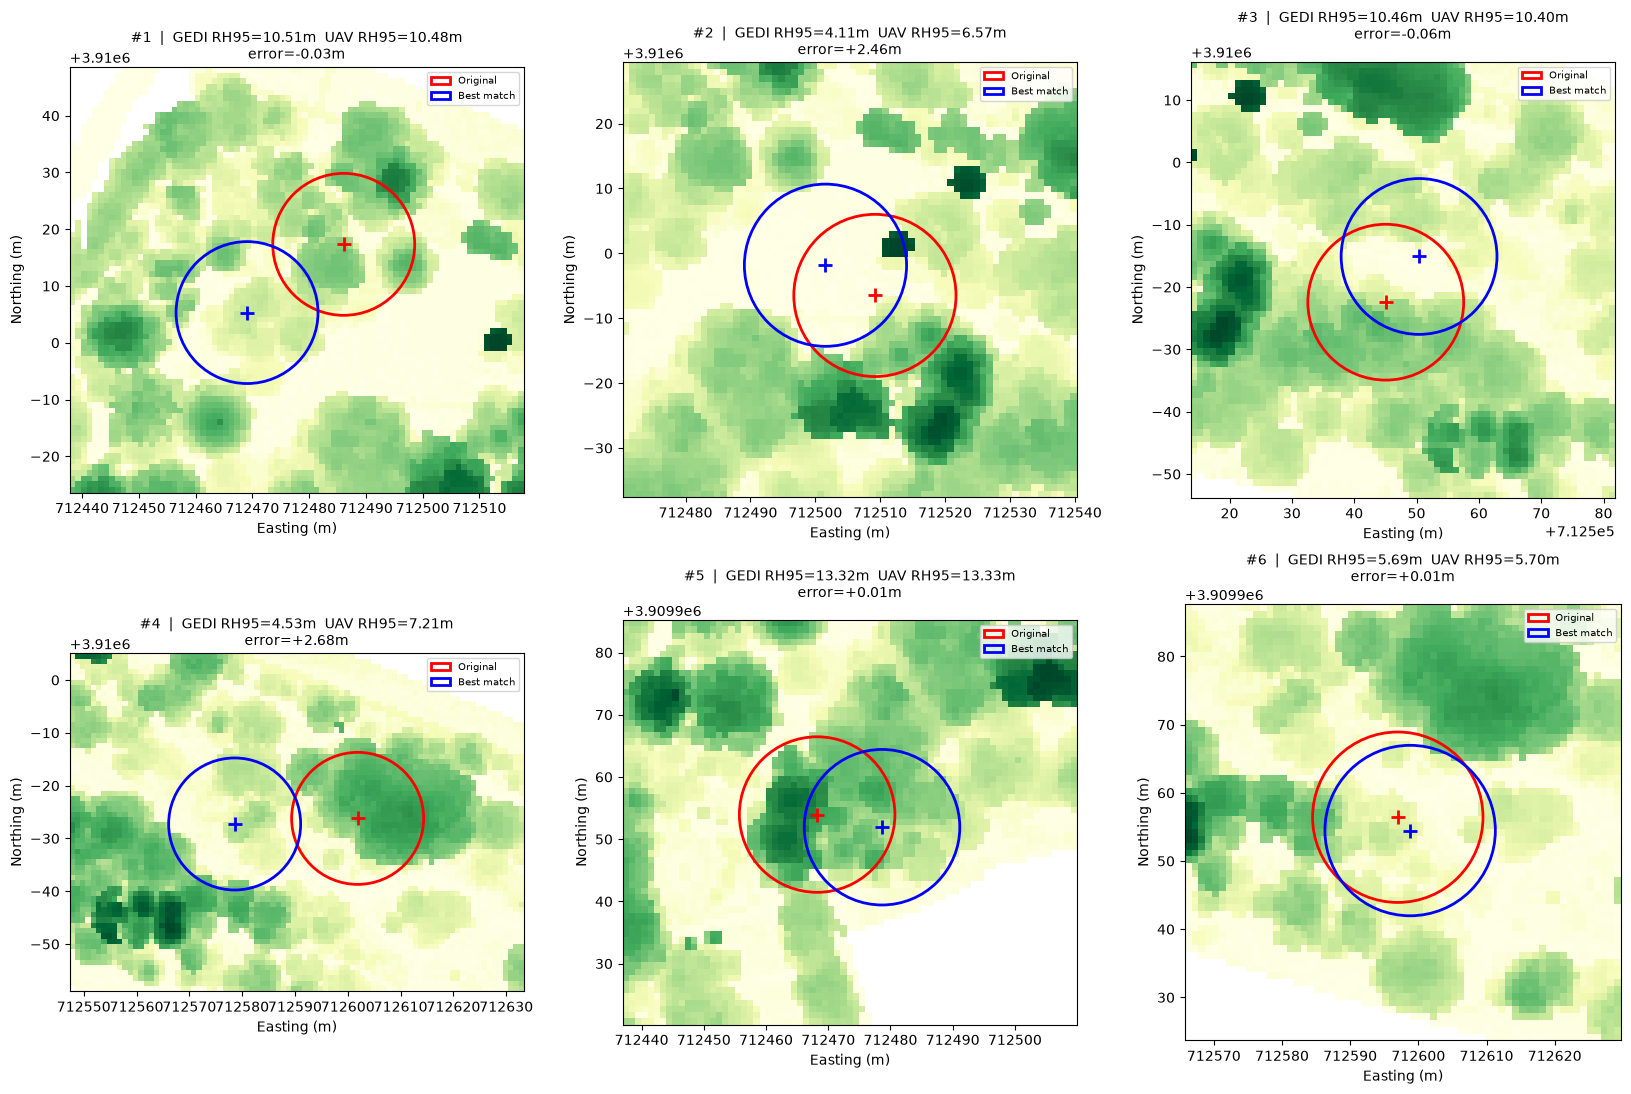

Best-match grid figure saved.


In [20]:
# ════════════════════════════════════════════════════════════════════════════
# STEP K — Grid plot: original vs. best-matching buffer, per footprint
# ════════════════════════════════════════════════════════════════════════════
from rasterio.windows import from_bounds as window_from_bounds
from matplotlib.patches import Circle

n_footprints = len(best_matches)
n_cols = min(3, n_footprints)
n_rows = int(np.ceil(n_footprints / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

with rasterio.open(chm_path) as chm_src:
    chm_crs = chm_src.crs
    to_chm_crs = Transformer.from_crs(WGS84, chm_crs, always_xy=True)

    for ax_idx, (_, fp) in enumerate(best_matches.iterrows()):
        ax = axes[ax_idx]

        # Convert both the original and best-match points into CHM CRS
        x_orig, y_orig = to_chm_crs.transform(fp['lon_original'], fp['lat_original'])
        x_best, y_best = to_chm_crs.transform(fp['lon_shifted'], fp['lat_shifted'])

        # Build a display window that comfortably contains both buffers
        pad = BUFFER_RADIUS_M * 2.5
        min_x = min(x_orig, x_best) - pad
        max_x = max(x_orig, x_best) + pad
        min_y = min(y_orig, y_best) - pad
        max_y = max(y_orig, y_best) + pad

        window = window_from_bounds(min_x, min_y, max_x, max_y, transform=chm_src.transform)
        chm_crop = chm_src.read(1, window=window)
        crop_transform = chm_src.window_transform(window)

        # Display extent for imshow, matching the cropped raster's bounds
        extent = (
            crop_transform.c,
            crop_transform.c + chm_crop.shape[1] * crop_transform.a,
            crop_transform.f + chm_crop.shape[0] * crop_transform.e,
            crop_transform.f,
        )

        im = ax.imshow(chm_crop, extent=extent, cmap='YlGn', origin='upper')

        # Original footprint buffer (red)
        ax.add_patch(Circle((x_orig, y_orig), BUFFER_RADIUS_M,
                             fill=False, edgecolor='red', linewidth=2, label='Original'))
        ax.plot(x_orig, y_orig, 'r+', markersize=10, markeredgewidth=2)

        # Best-matching simulated buffer (blue)
        ax.add_patch(Circle((x_best, y_best), BUFFER_RADIUS_M,
                             fill=False, edgecolor='blue', linewidth=2, label='Best match'))
        ax.plot(x_best, y_best, 'b+', markersize=10, markeredgewidth=2)

        ax.set_title(
            f"#{int(fp['reading_order_id'])}  |  "
            f"GEDI RH95={fp['rh95_gedi']:.2f}m  UAV RH95={fp['rh95_uav_chm']:.2f}m\n"
            f"error={fp['rh95_error']:+.2f}m",
            fontsize=10
        )
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        ax.legend(fontsize=7, loc='upper right')
        ax.set_aspect('equal')

# Hide any unused subplot axes if grid is not fully filled
for ax_idx in range(n_footprints, len(axes)):
    axes[ax_idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(data_folder, f'{file_header}_best_match_grid.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Best-match grid figure saved.")